In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

zomato = pd.read_excel('BangaloreZomatoData.csv.xlsx')
rent = pd.read_excel('BangaloreHouseRentDtls.csv.xlsx')
salary = pd.read_excel('Software_Professional_Salaries.csv.xlsx')

print("ZOMATO:", zomato.shape)
print("RENT:", rent.shape)
print("SALARY:", salary.shape)

print("\nZOMATO columns:", zomato.columns.tolist())
print("\nRENT columns:", rent.columns.tolist())
print("\nSALARY columns:", salary.columns.tolist())

ZOMATO: (8923, 19)
RENT: (1080, 5)
SALARY: (22774, 6)

ZOMATO columns: ['Name', 'URL', 'Cuisines', 'Area', 'Timing', 'Full_Address', 'PhoneNumber', 'IsHomeDelivery', 'isTakeaway', 'isIndoorSeating', 'isVegOnly', 'Dinner Ratings', 'Dinner Reviews', 'Delivery Ratings', 'Delivery Reviews', 'KnownFor', 'PopularDishes', 'PeopleKnownFor', 'AverageCost']

RENT columns: ['Locality', 'MinPrice', 'MaxPrice', 'AvgRent', 'HouseType']

SALARY columns: ['Rating', 'Company Name', 'Job Title', 'Salary', 'Salaries Reported', 'Location']


In [17]:
print("ZOMATO nulls:\n", zomato.isnull().sum())

zomato = zomato.drop(['URL', 'Full_Address', 'PhoneNumber', 'Timing'], axis=1)

zomato = zomato.drop_duplicates()

zomato = zomato.dropna()

print("Zomato cleaned shape:", zomato.shape)

print("\nRENT nulls:\n", rent.isnull().sum())
rent = rent.dropna()
rent = rent.drop_duplicates()
print("Rent cleaned shape:", rent.shape)

print("\nSALARY nulls:\n", salary.isnull().sum())

salary = salary[salary['Location'].str.contains('India', na=False)]
salary = salary.dropna()
salary = salary.drop_duplicates()

print("Salary cleaned shape:", salary.shape)
print("\nSample salary data:")
print(salary.head())

ZOMATO nulls:
 Name                   0
URL                    0
Cuisines               0
Area                   0
Timing              3103
Full_Address           0
PhoneNumber            0
IsHomeDelivery         0
isTakeaway             0
isIndoorSeating        0
isVegOnly              0
Dinner Ratings         0
Dinner Reviews         0
Delivery Ratings       0
Delivery Reviews       0
KnownFor            8665
PopularDishes       7388
PeopleKnownFor      5439
AverageCost            0
dtype: int64
Zomato cleaned shape: (209, 15)

RENT nulls:
 Locality       0
MinPrice     223
MaxPrice     547
AvgRent        0
HouseType      0
dtype: int64
Rent cleaned shape: (531, 5)

SALARY nulls:
 Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
dtype: int64
Salary cleaned shape: (0, 6)

Sample salary data:
Empty DataFrame
Columns: [Rating, Company Name, Job Title, Salary, Salaries Reported, Location]
Index: []


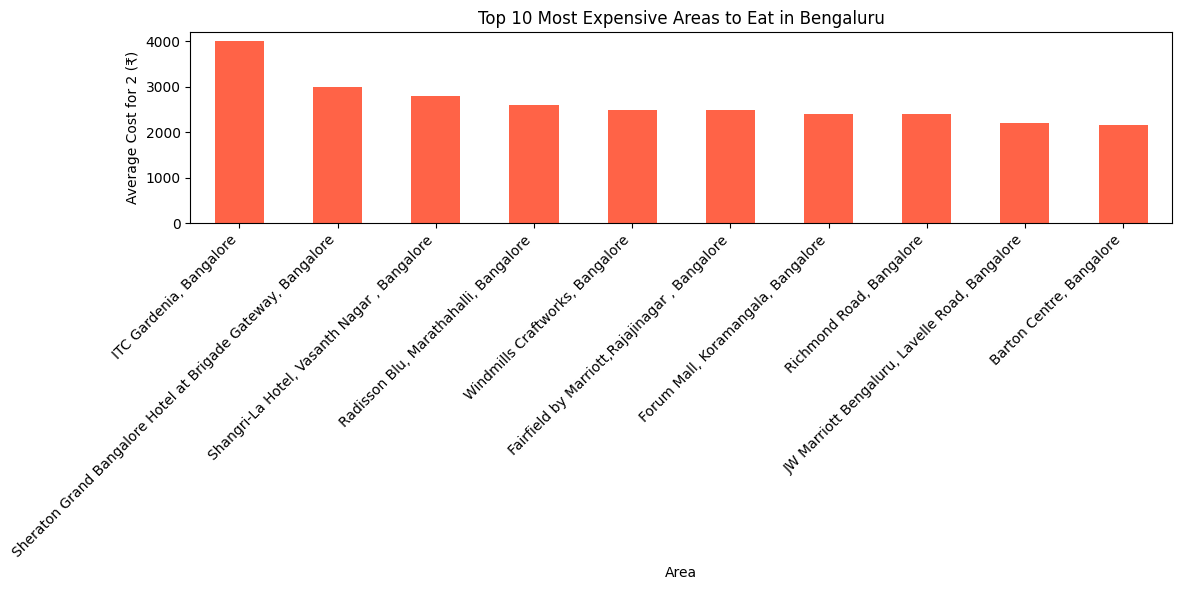

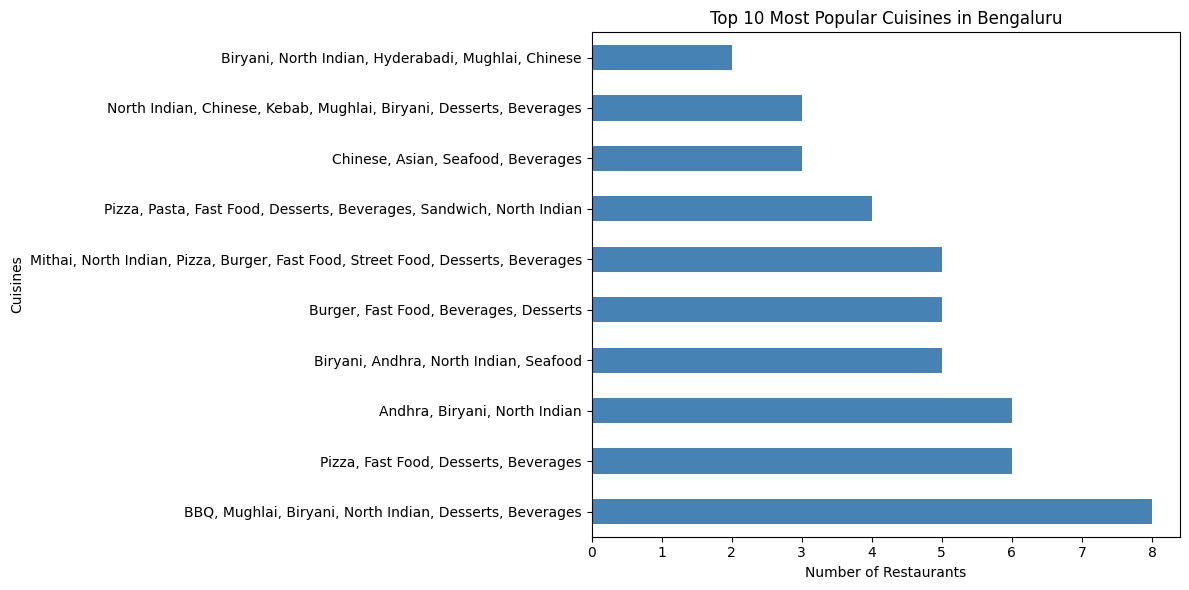

Charts 1 and 2 done!


In [18]:
plt.figure(figsize=(12,6))
area_cost = zomato.groupby('Area')['AverageCost'].mean().sort_values(ascending=False).head(10)
area_cost.plot(kind='bar', color='tomato')
plt.title('Top 10 Most Expensive Areas to Eat in Bengaluru')
plt.xlabel('Area')
plt.ylabel('Average Cost for 2 (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart1_food_cost.png')
plt.show()

plt.figure(figsize=(12,6))
zomato['Cuisines'].value_counts().head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Popular Cuisines in Bengaluru')
plt.xlabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('chart2_cuisines.png')
plt.show()

print("Charts 1 and 2 done!")

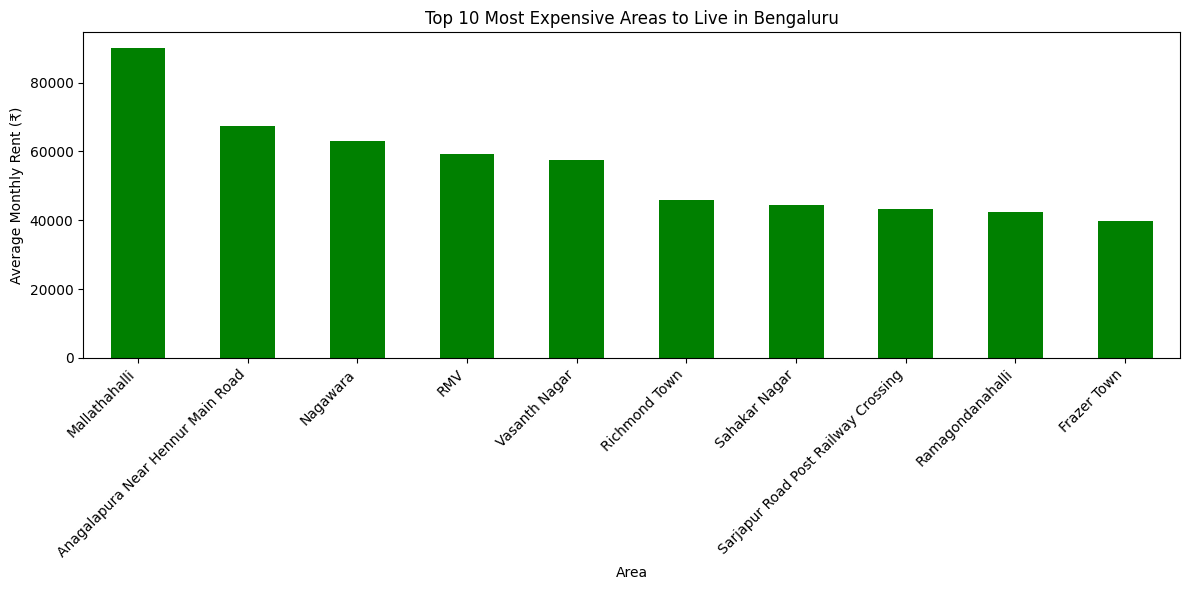

chart 3 is done!


In [19]:
plt.figure(figsize=(12,6))
rent_area = rent.groupby('Locality')['AvgRent'].mean().sort_values(ascending=False).head(10)
rent_area.plot(kind='bar', color='green')
plt.title('Top 10 Most Expensive Areas to Live in Bengaluru')
plt.xlabel('Area')
plt.ylabel('Average Monthly Rent (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart3_rent.png')
plt.show()
print("chart 3 is done!")

In [20]:
print(salary['Salary'].dtype)
print(salary['Salary'].head(10))
print(salary['Salary'].unique()[:10])

int64
Series([], Name: Salary, dtype: int64)
[]


In [21]:
print(salary['Location'].unique())
print("\nTotal rows:", len(salary))
print("\nSalary column sample:")
print(salary.head())

[]

Total rows: 0

Salary column sample:
Empty DataFrame
Columns: [Rating, Company Name, Job Title, Salary, Salaries Reported, Location]
Index: []


In [22]:
salary = pd.read_excel('Software_Professional_Salaries.csv.xlsx')
salary = salary.dropna()
salary = salary.drop_duplicates()

print("Salary shape:", salary.shape)
print("Columns:", salary.columns.tolist())
print(salary.head())

Salary shape: (22773, 6)
Columns: ['Rating', 'Company Name', 'Job Title', 'Salary', 'Salaries Reported', 'Location']
   Rating                      Company Name          Job Title   Salary  \
0     3.8                            Sasken  Android Developer   400000   
1     4.5  Advanced Millennium Technologies  Android Developer   400000   
2     4.0                         Unacademy  Android Developer  1000000   
3     3.8                SnapBizz Cloudtech  Android Developer   300000   
4     4.4            Appoids Tech Solutions  Android Developer   600000   

   Salaries Reported   Location  
0                  3  Bangalore  
1                  3  Bangalore  
2                  3  Bangalore  
3                  3  Bangalore  
4                  3  Bangalore  


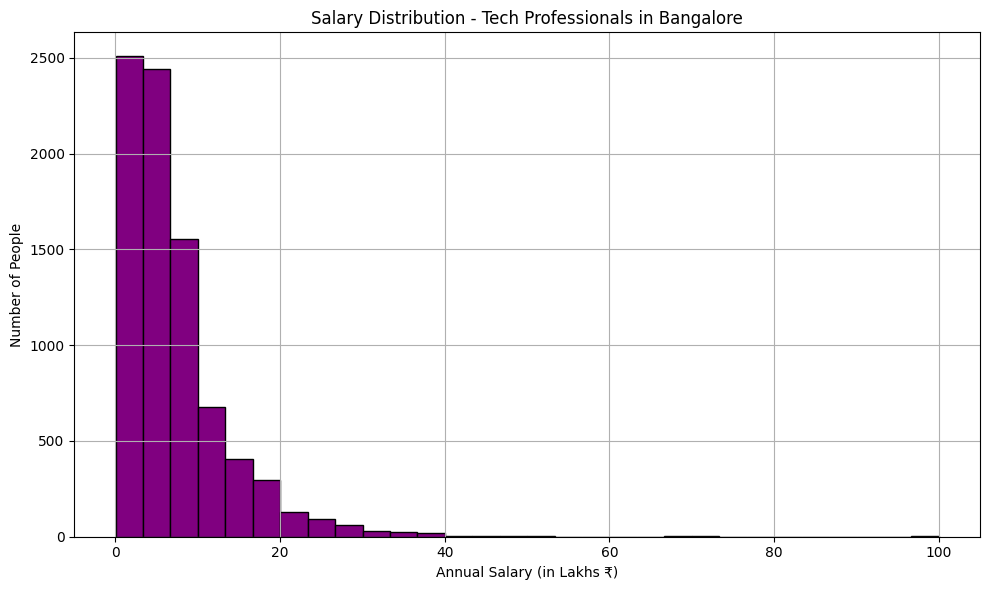

chart 4 is readyyy!!!


In [23]:
salary = salary[salary['Location'] == 'Bangalore']

salary['Salary_Lakhs'] = salary['Salary'] / 100000

plt.figure(figsize=(10,6))
salary['Salary_Lakhs'].hist(bins=30, color='purple', edgecolor='black')
plt.title('Salary Distribution - Tech Professionals in Bangalore')
plt.xlabel('Annual Salary (in Lakhs ₹)')
plt.ylabel('Number of People')
plt.tight_layout()
plt.savefig('chart4_salary.png')
plt.show()

print("chart 4 is readyyy!!!")

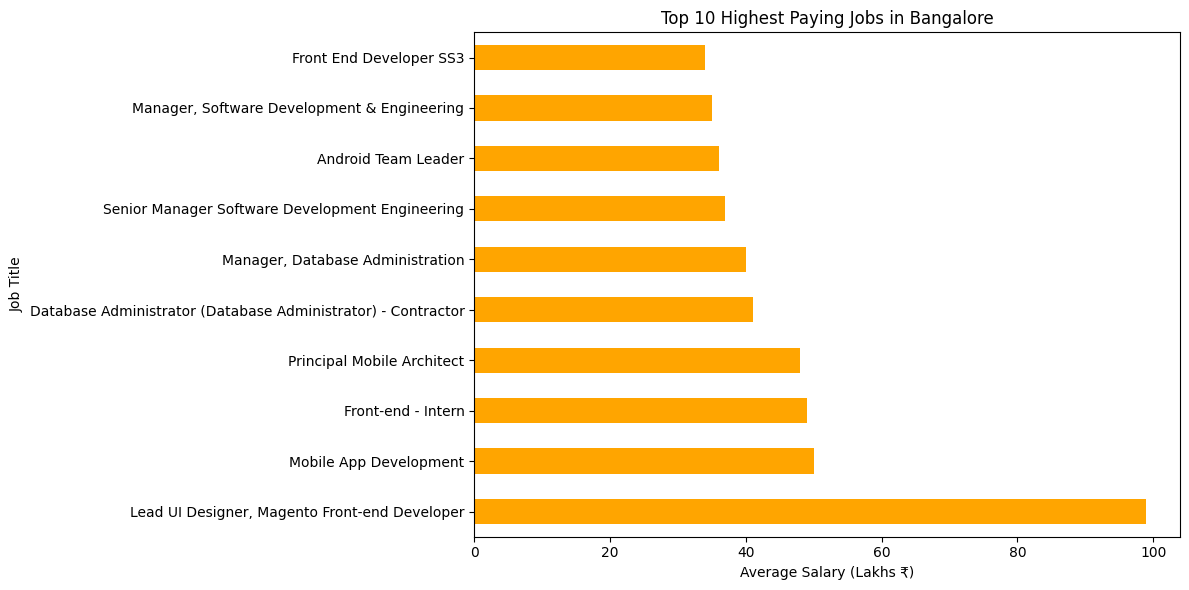

Chart 5 is readyy!!


In [24]:
plt.figure(figsize=(12,6))
top_jobs = salary.groupby('Job Title')['Salary_Lakhs'].mean().sort_values(ascending=False).head(10)
top_jobs.plot(kind='barh', color='orange')
plt.title('Top 10 Highest Paying Jobs in Bangalore')
plt.xlabel('Average Salary (Lakhs ₹)')
plt.tight_layout()
plt.savefig('chart5_jobs.png')
plt.show()

print("Chart 5 is readyy!!")

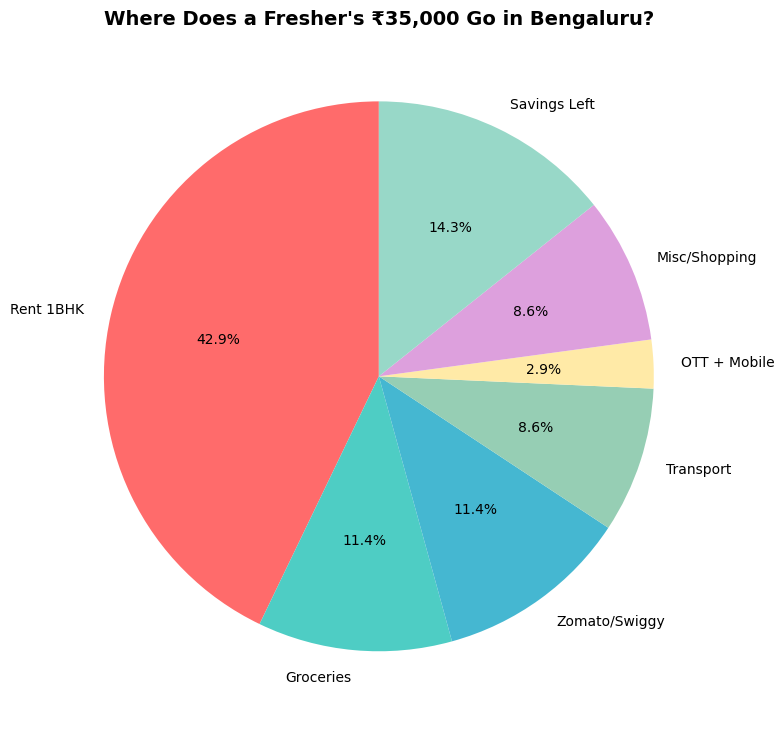

THE STAR CHART IS READY!!!


In [25]:
monthly_salary = 35000  # 4.2LPA fresher

expenses = {
    'Rent 1BHK': 15000,
    'Groceries': 4000,
    'Zomato/Swiggy': 4000,
    'Transport': 3000,
    'OTT + Mobile': 1000,
    'Misc/Shopping': 3000,
    'Savings Left': 5000
}

plt.figure(figsize=(8,8))
colors = ['#FF6B6B','#4ECDC4','#45B7D1',
          '#96CEB4','#FFEAA7','#DDA0DD','#98D8C8']
plt.pie(expenses.values(),
        labels=expenses.keys(),
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
plt.title("Where Does a Fresher's ₹35,000 Go in Bengaluru?",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_survival.png')
plt.show()

print("THE STAR CHART IS READY!!!")

In [26]:
import sqlite3

# Creating database
conn = sqlite3.connect(':memory:')
zomato.to_sql('zomato', conn, index=False)
rent.to_sql('rent', conn, index=False)
salary.to_sql('salary', conn, index=False)

# Query 1: Top 5 Cheapest Areas to Eat
q1 = pd.read_sql("""
SELECT Area, ROUND(AVG(AverageCost),0) as Avg_Cost
FROM zomato
GROUP BY Area
ORDER BY Avg_Cost ASC
LIMIT 5
""", conn)
print("TOP 5 CHEAPEST AREAS TO EAT:")
print(q1)

# Query 2: Top 5 Most Expensive Areas to Eat
q2 = pd.read_sql("""
SELECT Area, ROUND(AVG(AverageCost),0) as Avg_Cost
FROM zomato
GROUP BY Area
ORDER BY Avg_Cost DESC
LIMIT 5
""", conn)
print("\nTOP 5 MOST EXPENSIVE AREAS:")
print(q2)

# Query 3: Most Common Cuisine
q3 = pd.read_sql("""
SELECT Cuisines, COUNT(*) as Total
FROM zomato
GROUP BY Cuisines
ORDER BY Total DESC
LIMIT 5
""", conn)
print("\nTOP 5 CUISINES:")
print(q3)

# Query 4: Average Rent by House Type
q4 = pd.read_sql("""
SELECT HouseType, ROUND(AVG(AvgRent),0) as Avg_Rent
FROM rent
GROUP BY HouseType
ORDER BY Avg_Rent DESC
""", conn)
print("\nAVERAGE RENT BY HOUSE TYPE:")
print(q4)

# Query 5: Top Paying Jobs
q5 = pd.read_sql("""
SELECT "Job Title", ROUND(AVG(Salary)/100000,1) as Avg_Salary_Lakhs
FROM salary
GROUP BY "Job Title"
ORDER BY Avg_Salary_Lakhs DESC
LIMIT 5
""", conn)
print("\nTOP 5 PAYING JOBS:")
print(q5)

print("\nALL SQL QUERIES DONE! ")

TOP 5 CHEAPEST AREAS TO EAT:
                                    Area  Avg_Cost
0  ITPL Main Road, Whitefield, Bangalore     200.0
1                    Majestic, Bangalore     250.0
2               Seshadripuram, Bangalore     275.0
3                Basavanagudi, Bangalore     350.0
4                  Hosur Road, Bangalore     350.0

TOP 5 MOST EXPENSIVE AREAS:
                                                Area  Avg_Cost
0                            ITC Gardenia, Bangalore    4000.0
1  Sheraton Grand Bangalore Hotel at Brigade Gate...    3000.0
2        Shangri-La Hotel, Vasanth Nagar , Bangalore    2800.0
3              Radisson Blu, Marathahalli, Bangalore    2600.0
4                    Windmills Craftworks, Bangalore    2500.0

TOP 5 CUISINES:
                                            Cuisines  Total
0  BBQ, Mughlai, Biryani, North Indian, Desserts,...      8
1              Pizza, Fast Food, Desserts, Beverages      6
2                      Andhra, Biryani, North Indian      6
3

In [27]:
with pd.ExcelWriter('Bengaluru_Fresher_Analysis.xlsx',
                     engine='openpyxl') as writer:
    zomato.to_excel(writer, sheet_name='Zomato', index=False)
    rent.to_excel(writer, sheet_name='Rent', index=False)
    salary.to_excel(writer, sheet_name='Salary', index=False)

print("Excel file created! ")

Excel file created! 
